In [2]:
import os
os.environ['KAGGLE_USERNAME'] = 'aliaanasserr'
os.environ['KAGGLE_KEY'] = 'd0921bc48e590f61b98bdbbe5c62c34f'

import kaggle
kaggle.api.authenticate()

kaggle.api.dataset_download_files(
    'imsparsh/audio-speech-sentiment',
    path='./data',
    unzip=True
)

print("Dataset downloaded")


Dataset URL: https://www.kaggle.com/datasets/imsparsh/audio-speech-sentiment
Dataset downloaded


In [1]:
TRAIN_CSV = './data/TRAIN.csv'
TRAIN_DIR = './data/TRAIN/'
TEST_DIR  = './data/TEST/'

In [43]:
# Core libraries
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

# Audio processing
import librosa

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, MaxPooling1D, BatchNormalization, Dropout, Dense, GlobalAveragePooling1D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Warnings suppression
import warnings
warnings.filterwarnings('ignore')

# Random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [28]:
# Load dataset locally
train_data = pd.read_csv('./data/TRAIN.csv')
train_path = './data/TRAIN'

print("Dataset shape:", train_data.shape)
print("\nFirst few rows:")
print(train_data.head())
print("\nClass distribution:")
print(train_data['Class'].value_counts())

Dataset shape: (250, 2)

First few rows:
  Filename     Class
0  346.wav  Negative
1  163.wav   Neutral
2  288.wav  Negative
3  279.wav  Negative
4  244.wav  Negative

Class distribution:
Class
Negative    87
Positive    82
Neutral     81
Name: count, dtype: int64


In [29]:
def extract_features(audio_path):
    """Extract MFCC features from audio file."""
    audio, sample_rate = librosa.load(audio_path, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=128)
    return np.mean(mfccs.T, axis=0)

In [30]:
#Load all audio files and extract features
def load_data(data, path):
    """Load all audio files and extract MFCC features."""
    features, target = [], []
    for index, row in tqdm(data.iterrows(), desc="Loading audio files"):
        audio_path = os.path.join(path, row['Filename'])
        features.append(extract_features(audio_path))
        target.append(row['Class'])
    return np.array(features), np.array(target)

# Extract features from all training audio
X, y = load_data(train_data, train_path)
print(f"Loaded {len(X)} training samples")
print(f"Feature shape: {X.shape}")

Loading audio files: 250it [00:15, 15.88it/s]

Loaded 250 training samples
Feature shape: (250, 128)


In [31]:
#Encode labels and split data
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(f"Classes: {encoder.classes_}")

# Add channel dimension
X = np.expand_dims(X, axis=-1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Classes: ['Negative' 'Neutral' 'Positive']
X_train: (200, 128, 1), X_test: (50, 128, 1)
y_train: (200,), y_test: (50,)


In [32]:
#Baseline for Comparison
# Least performing model predictions based on majority class 
baseline_accuracy = max(np.bincount(y_train)) / len(y_train)
print(f"Baseline accuracy (majority class): {baseline_accuracy:.2%}")
# our model should perform better than this baseline to be considered effective like (baseline -> 35% , our model -> 70%)

Baseline accuracy (majority class): 34.50%


In [41]:
"""num_class = len(encoder.classes_)
#input_shape = (X_train.shape[1], X_train.shape[2]) # (128, 1)
model = Sequential([
        #32  filter
        Conv1D(32, kernel_size=3, activation='relu', padding='same',input_shape=(128,1)), 
        #normalization after convolution layer to stabilize and speed up training
        BatchNormalization(), 
        #downsample the feature maps by taking the maximum value in each pool size window
        # which helps to reduce the spatial dimensions and retain important features
        MaxPooling1D(pool_size=2),
        #randomly set 20% of the input units to 0 during training to prevent overfitting and improve generalization
        Dropout(0.4),
        
        #64 filter 
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),
        
        #reduces each feature map to a single value by taking the average, 
        #which helps to reduce the number of parameters and prevent overfitting
        GlobalAveragePooling1D(), 

        Dense(64, activation='relu'),#fully connected layer with 64 neurons and ReLU activation to learn complex patterns from the extracted features
        Dropout(0.5),

        Dense(num_class, activation='softmax')#output layer with softmax activation for multi-class classification(probability distribution over classes)
    ])

model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()"""

"num_class = len(encoder.classes_)\n#input_shape = (X_train.shape[1], X_train.shape[2]) # (128, 1)\nmodel = Sequential([\n        #32  filter\n        Conv1D(32, kernel_size=3, activation='relu', padding='same',input_shape=(128,1)), \n        #normalization after convolution layer to stabilize and speed up training\n        BatchNormalization(), \n        #downsample the feature maps by taking the maximum value in each pool size window\n        # which helps to reduce the spatial dimensions and retain important features\n        MaxPooling1D(pool_size=2),\n        #randomly set 20% of the input units to 0 during training to prevent overfitting and improve generalization\n        Dropout(0.4),\n\n        #64 filter \n        Conv1D(64, kernel_size=3, activation='relu', padding='same'),\n        BatchNormalization(),\n        MaxPooling1D(pool_size=2),\n        Dropout(0.4),\n\n        #reduces each feature map to a single value by taking the average, \n        #which helps to reduce the

C. Why Conv1D and Not Conv2D?
Data structure matters:

Conv2D (2D Convolution):
- Used for: Images (height × width × channels)
- Our data: (batch, 128, 1) - just a 1D sequence
- 2D kernels would be wasteful

Conv1D (1D Convolution):
- Used for: Time series, sequences, audio
- Our data: (batch, 128, 1) - MFCC features over time
- Kernel slides along the 128-dimension only
- Efficient: learns patterns in sequential features
Analogy:

Conv2D: Like scanning an image with a 2D filter (detecting edges, shapes)
Conv1D: Like scanning a heartbeat signal with a 1D filter (detecting patterns over time)
MFCCs are already a compressed 1D representation, so Conv1D is perfect—it learns how different MFCC features relate to emotion without unnecessary 2D operations.

In [44]:
num_class = len(encoder.classes_)

model = Sequential([
    # USE this format in synatx (keras.layers."layername(params)")
    #convolutional layer with 16 filters, kernel size of 3, ReLU activation, and input shape of (128,1) for MFCC features
    Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(128,1)),
    #downsample the feature maps by taking the maximum value in each pool size window
    MaxPooling1D(pool_size=2),
    #flattens the 2D feature maps into a 1D vector to feed into the fully connected layers
    Flatten(),
    #fully connected layer with 64 neurons and ReLU activation to learn complex patterns from the extracted features
    Dense(units=64, activation='relu'),
    #randomly set 50% of the input units to 0 during training to prevent overfitting and improve generalization
    Dropout(rate=0.5),
    #output layer with softmax activation for multi-class classification(probability distribution over classes)
    Dense(units=num_class, activation='softmax')
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 126, 16)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 63, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1008)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        64,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,835 (253.26 KB)

 Trainable params: 64,835 (253.26 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

save_point = keras.callbacks.ModelCheckpoint(
    'audio.keras', save_best_only=True, verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, save_point],
    verbose=1
)


Epoch 1/50
1/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2812 - loss: 21.7484
Epoch 1: val_loss improved from None to 3.36273, saving model to audio.keras

Epoch 1: finished saving model to audio.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.3600 - loss: 13.0663 - val_accuracy: 0.3400 - val_loss: 3.3627
Epoch 2/50
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.2500 - loss: 11.4147
Epoch 2: val_loss improved from 3.36273 to 1.09698, saving model to audio.keras

Epoch 2: finished saving model to audio.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3750 - loss: 7.8896 - val_accuracy: 0.5600 - val_loss: 1.0970
Epoch 3/50
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5938 - loss: 4.8812
Epoch 3: val_loss improved from 1.09698 to 0.35344, saving model to audio.keras

Epoch 3: finished saving model to audio.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5800 - loss: 3.7063 - val_accuracy: 0.8400 - val_loss: 0.3534
Epoch 4/50
1/7 ━━━━━━━━━━━━━━

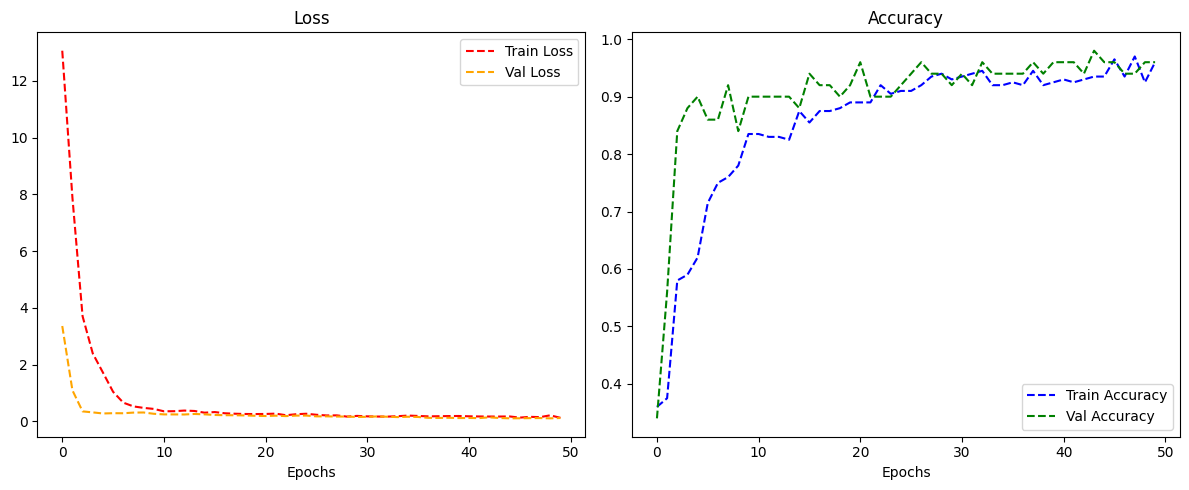

In [46]:
hist = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist['loss'], '--', color='red', label='Train Loss')
plt.plot(hist['val_loss'], '--', color='orange', label='Val Loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epochs')

plt.subplot(1, 2, 2)
plt.plot(hist['accuracy'], '--', color='blue', label='Train Accuracy')
plt.plot(hist['val_accuracy'], '--', color='green', label='Val Accuracy')
plt.legend()
plt.title('Accuracy')
plt.xlabel('Epochs')

plt.tight_layout()
plt.show()

In [48]:
#TODO Load best model and make predictions
model = keras.models.load_model('audio.keras')

#Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

#Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9600 - loss: 0.1084 
Test Loss: 0.1084
Test Accuracy: 0.9600
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.94      0.94        18
     Neutral       1.00      1.00      1.00        16
    Positive       0.94      0.94      0.94        16

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



In [49]:
print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

#Overall accuracy
test_accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# # Precision, Recall, F1
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"\nPrecision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")


TEST SET EVALUATION
Accuracy: 0.9600 (96.00%)

Precision (Macro): 0.9606
Precision (Weighted): 0.9600
Recall (Macro): 0.9606
Recall (Weighted): 0.9600
F1-Score (Macro): 0.9606
F1-Score (Weighted): 0.9600


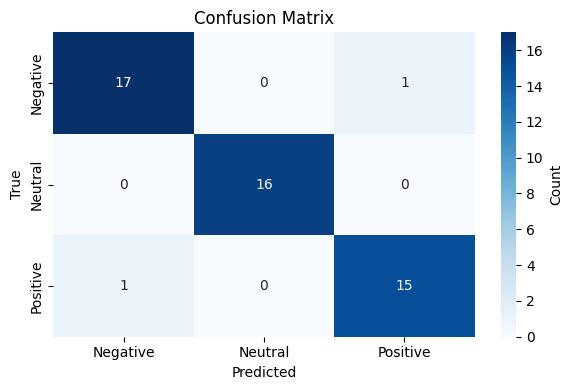


Confusion Matrix - Interpretation:
  Diagonal: Correct predictions
  Off-diagonal: Misclassifications


In [52]:
#visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix - Interpretation:")
print(f"  Diagonal: Correct predictions")
print(f"  Off-diagonal: Misclassifications")